# Introducción

El presente proyecto implementa un modelo de aprendizaje no supervisado (Clustering) enfocado en la segmentación estratégica de consumidores para una plataforma digital de entrega de comida a domicilio (Food Delivery). A diferencia de los modelos supervisados que buscan predecir un comportamiento específico, el objetivo aquí es descubrir estructuras y patrones ocultos en los hábitos de consumo de los clientes.

Metodología: Se utilizará la metodología RFM (Recencia, Frecuencia y Valor Monetario) como técnica de ingeniería de características, transformando un registro histórico transaccional plano en un dataset analítico a nivel de cliente único. Finalmente, aplicaremos el algoritmo K-Means para agrupar a los usuarios en segmentos con características homogéneas, permitiendo el diseño de estrategias comerciales, programas de lealtad y campañas de retención personalizadas.

Dicho set de datos de ha obtenido de: https://www.kaggle.com/datasets/sujalsuthar/food-delivery-order-history-data

# Fase 1: Carga de Datos y Diagnóstico Inicial

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# para importar el archivo csv a trabajar
df = pd.read_csv(r"C:\Users\carlo\OneDrive\Escritorio\Proyecto Clustering\order_history_kaggle_data.csv")

# imprimiendo pequeña muestra para confirmar la carga correcta del archivo.
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [30]:
# Para entender un poco acerca del set de datos:

resumen_general = pd.DataFrame({
    'Tipo de dato': df.dtypes,
    'Valores únicos': df.nunique(),
    'Ejemplos': [df[col].unique()[:6] for col in df.columns]
})

resumen_general

,Tipo de dato,Valores únicos,Ejemplos
Restaurant ID,int64,21,"[20320607, 20554001, 20635699, 20659868, 20882..."
Restaurant name,object,6,"[Swaad, Aura Pizzas, Dilli Burger Adda, Tandoo..."
Subzone,object,8,"[Sector 4, Greater Kailash 2 (GK2), DLF Phase ..."
City,object,1,[Delhi NCR]
Order ID,int64,21321,"[6168884918, 6170707559, 6169375019, 615167743..."
Order Placed At,object,19114,"[11:38 PM, September 10 2024, 11:34 PM, Septem..."
Order Status,object,6,"[Delivered, Returned, Rejected, Return cancell..."
Delivery,object,1,[Zomato Delivery]
Distance,object,22,"[3km, 2km, <1km, 1km, 6km, 4km]"
Items in order,object,6123,"[1 x Grilled Chicken Jamaican Tender, 1 x Gril..."


### Variables

**1. Identificadores y Datos de Origen**

Restaurant ID (int64): Identificador numérico único asignado a cada restaurante en la plataforma.

Restaurant name (object / texto): Nombre comercial del establecimiento (ej. Swaad, Aura Pizzas). El dataset cuenta con 6 restaurantes principales mapeados.

Subzone (object / texto): Subzona o área vecinal específica de localización del restaurante (ej. Sector 4, Greater Kailash 2). Cuenta con 8 subzones únicas.

City (object / texto): Ciudad donde opera el servicio. Al tener una cardinalidad de 1 (Delhi NCR), es una variable constante.

Order ID (int64): Identificador único de cada transacción/orden individual generada en la plataforma. Es la clave para contabilizar la frecuencia.

Customer ID (object / texto): Código alfanumérico (hash) único que identifica al usuario comprador. Es la variable central para realizar la agregación grupal y el clustering.

**2. Datos Temporales y Logísticos de la Orden**

Order Placed At (object / texto): Marca de tiempo (Timestamp) compuesta por hora y fecha que registra el momento exacto en el que el cliente confirmó su orden (ej. 11:38 PM, September 10 2024).

Order Status (object / texto): Estado de la orden en su ciclo de vida final logístico. Cuenta con 6 estados únicos (Delivered, Returned, Rejected, Return cancelled, etc.).

Delivery (object / texto): Modalidad o proveedor logístico responsable de la entrega. En la muestra revisada figura como Zomato Delivery, operando de forma constante.

Distance (object / texto): Distancia aproximada medida en rangos kilométricos entre el restaurante y la dirección de entrega del cliente (ej. 3km, 2km, <1km).

**3. Detalles de los Productos**
Items in order (object / texto): String plano que detalla la lista de productos adquiridos con su respectiva cantidad por renglón (ej. 1 x Grilled Chicken Jamaican Tender).

Instructions (object / texto): Notas o comentarios en texto libre añadidos por el usuario con indicaciones para el restaurante o el repartidor (ej. Please provide garlic aioli dip).

**4. Estructura de Costos, Descuentos y Facturación**

Discount construct (object / texto): Descripción de la regla o campaña de mercadotecnia aplicada a la orden (ej. 40% off upto Rs.80, Flat Rs.175 off).

Bill subtotal (float64): Costo bruto acumulado únicamente de los alimentos seleccionados, previo a impuestos, empaques o envío.

Packaging charges (float64): Cargos financieros imputados al cliente por concepto de empaquetado y contenedores de los alimentos.

Restaurant discount (Promo) (float64): Monto monetario descontado de la orden absorbido directamente por las campañas promocionales activas del restaurante.

Restaurant discount (Flat offs, Freebies & others) (float64): Deducciones monetarias debidas a descuentos planos fijos, productos de regalo (freebies) u otras condiciones de cortesía comercial.

Gold discount (float64): Descuento adicional aplicado si el cliente pertenece al programa de membresía o lealtad Premium de la app (Gold).

Brand pack discount (float64): Descuento acumulado derivado de paquetes promocionales o cupones específicos de la marca del restaurante.

Total (float64): Monto neto final pagado de forma efectiva por el cliente. Contempla la suma del subtotal, empaques y la deducción de todos los esquemas de descuento aplicados. Es el flujo de ingreso real percibido.

**5. Calificaciones y Reseñas (Feedback)**

Rating (float64): Puntuación entera otorgada por el cliente respecto a su satisfacción general con la orden (escala del 1.0 al 5.0).

Review (object / texto): Reseña textual redactada por el usuario evaluando la experiencia o la calidad de la comida.

**6. Cancelaciones, Penalizaciones e Indicadores de Tiempo (KPIs)**

Cancellation / Rejection reason (object / texto): Justificación registrada cuando una orden no concluye con éxito, identificando la responsabilidad (ej. Cancelled by Zomato, Cancelled by Customer).

Restaurant compensation (Cancellation) (float64): Monto económico transferido al restaurante como compensación cuando la orden es cancelada por factores ajenos a su operación.

Restaurant penalty (Rejection) (float64): Penalización económica aplicada al restaurante cuando rechaza injustificadamente una solicitud de orden viable.

KPT duration (minutes) (float64): Kitchen Preparation Time. Tiempo medido en minutos que le toma al personal de cocina preparar el pedido desde que se acepta hasta que se marca como listo.

Rider wait time (minutes) (float64): Tiempo en minutos que el repartidor asignado pasa esperando físicamente en las instalaciones del restaurante hasta recibir el paquete.

Order Ready Marked (object / texto): Métrica de auditoría interna sobre la precisión del restaurante al notificar el estatus de la comida (Correctly, Incorrectly, Missed).

Customer complaint tag (object / texto): Etiqueta categórica asignada por el equipo de soporte al cliente para clasificar quejas (ej. Poor taste or quality, Non-refunded complaint).

In [31]:
# Para verificar "completitud" de los datos:

print("Valores faltantes representados en '%' para cada variable")
(df.isnull().sum()/df.shape[0])* 100

Valores faltantes representados en '%' para cada variable


Restaurant ID                                          0.000000
Restaurant name                                        0.000000
Subzone                                                0.000000
City                                                   0.000000
Order ID                                               0.000000
Order Placed At                                        0.000000
Order Status                                           0.000000
Delivery                                               0.000000
Distance                                               0.000000
Items in order                                         0.000000
Instructions                                          96.623048
Discount construct                                    25.786783
Bill subtotal                                          0.000000
Packaging charges                                      0.000000
Restaurant discount (Promo)                            0.000000
Restaurant discount (Flat offs, Freebies

### Diagnóstico de Calidad y Completitud de los Datos

El análisis de valores faltantes revela que las variables críticas para el núcleo del modelado no supervisado (**Customer ID, Order ID, Order Placed At, Total y Order Status**) presentan un **0.0% de nulos**, garantizando la total integridad y viabilidad para la construcción de la **matriz RFM**.

**Respecto a las variables que presentan datos faltantes**: se determina que estos no corresponden a fallas de captura, sino a la naturaleza operativa del negocio y al comportamiento del usuario:

**Incidencias y Penalizaciones (Cancellation reason, Restaurant compensation, Restaurant penalty > 99% nulos)**: Al ser la gran mayoría de los pedidos entregados con éxito, estas columnas solo se activan en escenarios excepcionales de fricción operativa.

**Interacción Opcional del Cliente (Review 98.61%, Instructions 96.62%, Rating 88.31% nulos)**: Representan campos de texto libre o calificaciones voluntarias que el consumidor promedio decide omitir tras recibir su orden.

**Campañas de Marketing (Discount construct 25.79% nulos)**: Este porcentaje representa orgánicamente a los usuarios que realizaron su compra pagando la tarifa regular, sin interactuar con cupones o promociones activas.

Estas variables con nulos no afectarán el desarrollo del algoritmo y se preservarán con fines descriptivos para la fase final de perfilamiento comercial.

--------------------------------

# Fase 2.- Limpieza, Preprocesamiento e Ingeniería de Características (RFM)

El objetivo primordial de esta fase consiste en ejecutar una transformación estructural profunda sobre el set de datos, migrando de un registro bruto de carácter transaccional (donde la unidad mínima de análisis es la orden individual) hacia un dataset analítico estructurado a nivel de cliente único (Customer ID). En el entorno de la analítica comercial, este paso es fundamental para consolidar lo que se conoce como el perfil transaccional del consumidor.

Para asegurar la viabilidad matemática del algoritmo de aprendizaje no supervisado y maximizar el valor estratégico de los segmentos, este proceso se ejecutará bajo cuatro pilares metodológicos:

1.- Depuración de Fricción Operativa (Filtrado): Se aislarán exclusivamente las transacciones exitosas (Delivered), descartando cancelaciones o rechazos que distorsionen los hábitos de consumo real o inflen artificialmente el valor del cliente

2.- Optimización de Memoria (Reducción de Dimensionalidad): Se preservarán únicamente las variables maestras (Customer ID, Order ID, Order Placed At y Total) para agilizar el pipeline de procesamiento y mantener un enfoque analítico compacto.

3.- Estandarización Temporal (Parseo de Fechas): Se transformarán las marcas de tiempo textuales a objetos cronológicos nativos de Python, permitiendo realizar cálculos de distancia matemática en el tiempo.

4.- Ingeniería de Características (Agregación RFM): Se sintetizará el comportamiento histórico de cada usuario en las tres dimensiones clave de la lealtad comercial: Recencia (tiempo desde su última actividad), Frecuencia (volumen de transacciones) y Monto (flujo de capital aportado a la plataforma).

Al concluir esta etapa, el set de datos estará geométricamente unificado y listo para su correspondiente auditoría estadística en la fase exploratoria.


In [32]:
 # por buenas prácticas y para no alterar el set de datos original, se crea una copia sobre la cuál se trabajará:
df_copy = df.copy()
df_copy.head().T

,0,1,2,3,4
Restaurant ID,20320607,20320607,20320607,20320607,20320607
Restaurant name,Swaad,Swaad,Swaad,Swaad,Swaad
Subzone,Sector 4,Sector 4,Sector 4,Sector 4,Sector 4
City,Delhi NCR,Delhi NCR,Delhi NCR,Delhi NCR,Delhi NCR
Order ID,6168884918,6170707559,6169375019,6151677434,6167540897
Order Placed At,"11:38 PM, September 10 2024","11:34 PM, September 10 2024","03:52 PM, September 10 2024","03:45 PM, September 10 2024","03:04 PM, September 10 2024"
Order Status,Delivered,Delivered,Delivered,Delivered,Delivered
Delivery,Zomato Delivery,Zomato Delivery,Zomato Delivery,Zomato Delivery,Zomato Delivery
Distance,3km,2km,<1km,2km,2km
Items in order,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...","1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",1 x Bone in Peri Peri Grilled Chicken,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...","1 x Peri Peri Krispers, 1 x Fried Chicken Anga..."


### 1.- Filtrado Operativo

In [33]:
print(f'tamaño del data set completo:', df_copy.shape)
df_copy = df_copy[df_copy['Order Status'] == 'Delivered']
print(f'tamaño del data set con solo pedido entregados:', df_copy.shape)

tamaño del data set completo: (21321, 29)
tamaño del data set con solo pedido entregados: (21131, 29)


### 2.-  Reducción de dimensionalidad

Ahora que el Filtrado Operativo está listo, corresponde realizar la Reducción de dimensionalidad inicial. En este paso se va a crear un DataFrame optimizado conservando únicamente las 4 columnas core que se necesitan para construir el RFM:

Customer ID (para saber de quién es la orden).

Order ID (para contar la frecuencia).

Order Placed At (para calcular la recencia).

Total (La columna de facturación neta para el monto).

In [34]:
df_rfm_core = pd.DataFrame(df_copy[['Customer ID','Order ID','Order Placed At','Total']])
df_rfm_core.shape

(21131, 4)

In [35]:
print('Muestra del nuevo set de datos core')
df_rfm_core.head()

Muestra del nuevo set de datos core


,Customer ID,Order ID,Order Placed At,Total
0,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,6168884918,"11:38 PM, September 10 2024",666.75
1,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,6170707559,"11:34 PM, September 10 2024",1054.20
2,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,6169375019,"03:52 PM, September 10 2024",241.50
3,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,6151677434,"03:45 PM, September 10 2024",567.00
4,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,6167540897,"03:04 PM, September 10 2024",529.20


### 3.- Parseo de fechas

Qué se hace: Se transforma la columna Order Placed At (que actualmente Python lee como texto o cadena de caracteres "object") a un tipo de dato nativo de fecha (datetime64).

Por qué se hace: Las fechas en formato de texto no permiten realizar operaciones aritméticas. Para poder calcular cuántos días han pasado desde la última compra de un cliente, se necesita que Python entienda el orden cronológico exacto de las horas, meses y años de esa cadena de texto.

In [36]:
df_rfm_core['Order Placed At'] = pd.to_datetime(df_rfm_core['Order Placed At'], format= "%I:%M %p, %B %d %Y")
df_rfm_core.dtypes

Customer ID                object
Order ID                    int64
Order Placed At    datetime64[ns]
Total                     float64
dtype: object

### 4. Agregación Transaccional (La Construcción del RFM)

Que se hace: Agrupamos todo el historial usando el Customer ID como eje central y calculamos matemáticamente las tres dimensiones del modelo:

Recencia ($R$): Buscamos la fecha de la última orden de cada cliente y calculamos cuántos días de distancia tiene respecto al "día de hoy" del dataset (que se define como la fecha más reciente registrada en toda la plataforma).

Frecuencia ($F$): Contamos el número de pedidos únicos (Order ID) que ha completado cada usuario

Monto ($M$): Sumamos el dinero real efectivo (Total) de todas sus compras.

In [37]:
# para encontrar la fecha máxima en las órdenes entregadas
fecha_maxima = df_rfm_core['Order Placed At'].max()
print(fecha_maxima)

# Establecer la fecha de referencia sumando 1 día (el "hoy" del análisis)
fecha_referencia = fecha_maxima + pd.Timedelta(days=1)
print(fecha_referencia)

2025-01-31 23:59:00
2025-02-01 23:59:00


In [38]:
# Aplicar la agregación por cliente único
df_rfm = df_rfm_core.groupby('Customer ID').agg({
    # Para Recencia: Restamos la última fecha de la fecha de referencia y extraemos los días
    'Order Placed At': lambda x: (fecha_referencia - x.max()).days,
    # Para Frecuencia: Contamos las órdenes únicas entregadas
    'Order ID': 'nunique',
    # Para Monto: Sumamos el gasto total neto
    'Total': 'sum'
}).reset_index()

# Renombrar las columnas con sus términos analíticos formales
df_rfm.columns = ['Customer ID', 'Recencia', 'Frecuencia', 'Monto']

print(f"Dimensiones finales del dataset RFM: {df_rfm.shape}")
df_rfm.head()

Dimensiones finales del dataset RFM: (11545, 4)


,Customer ID,Recencia,Frecuencia,Monto
0,000285ae83ecf06a92b936d4f5b74342edb0e1940e1f00...,123,3,1360.80
1,001ab5fc3ee158b4d22e106897cee9b355e6eed50f163e...,22,1,1332.40
2,001fdf2511dd137361424c9c15ea54774476691ceec5fa...,50,1,1352.40
3,002afbd83626f0c699892fcb07b2ddf3858911482647b6...,54,4,3222.49
4,00360c54a3538e702016303eb89a7c09b0b184505de311...,69,3,2019.15


-----------------------------------------------------

# Fase 3: Análisis Exploratorio de Datos (EDA)

In [39]:
# Para poder entender la distribución de las variables:

# 1. Seleccionar las variables de interés desde df_rfm
variables_numericas = df_rfm[['Recencia', 'Frecuencia', 'Monto']]

# 2. Calcular estadísticas básicas, asimetría y curtosis
estadisticas = variables_numericas.describe().T
asimetria = variables_numericas.skew().rename('asimetría')
curtosis = variables_numericas.kurtosis().rename('curtosis')

# 3. para concatenar todo en una sola tabla limpia
resumen_estadistico = pd.concat([estadisticas, asimetria, curtosis], axis=1)

# Mostrando el resultado
resumen_estadistico

,count,mean,std,min,25%,50%,75%,max,asimetría,curtosis
Recencia,11545.0,68.479168,44.346890,1.0,31.0,66.0,105.00,153.00,0.206887,-1.135653
Frecuencia,11545.0,1.830316,2.012190,1.0,1.0,1.0,2.00,60.00,7.129551,106.437585
Monto,11545.0,1249.318299,1507.452186,53.0,504.0,785.4,1412.25,27767.93,5.173801,46.163445


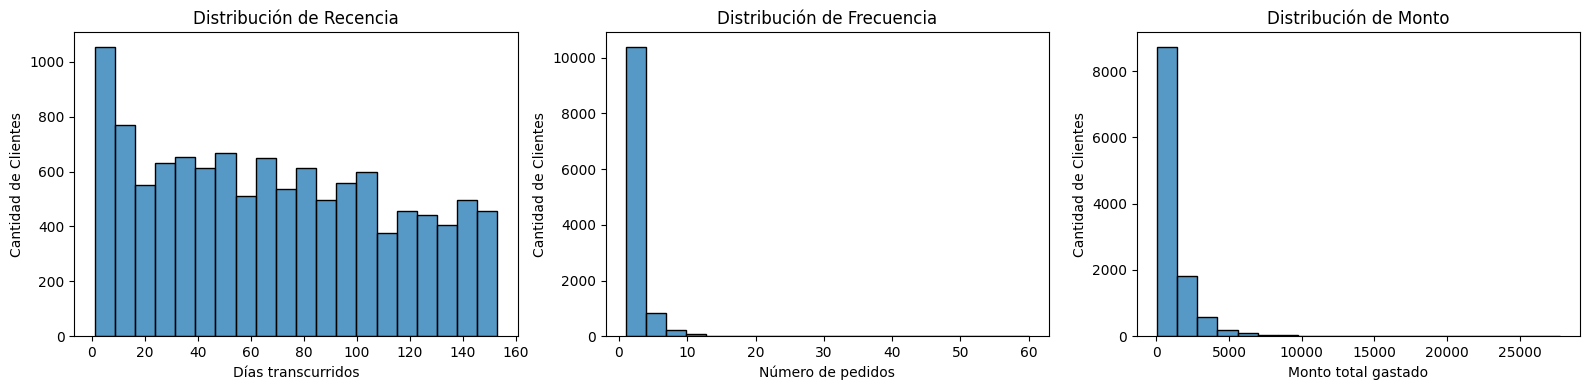

In [40]:
# Para visualizar

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

variables = ['Recencia', 'Frecuencia', 'Monto']
unidades = ['Días transcurridos', 'Número de pedidos', 'Monto total gastado']

for i, var in enumerate(variables):
    sns.histplot(variables_numericas[var], bins=20, ax=axes[i])
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(unidades[i])  # Etiqueta para eje X
    axes[i].set_ylabel('Cantidad de Clientes')  # Etiqueta para eje Y

plt.tight_layout()
plt.show()

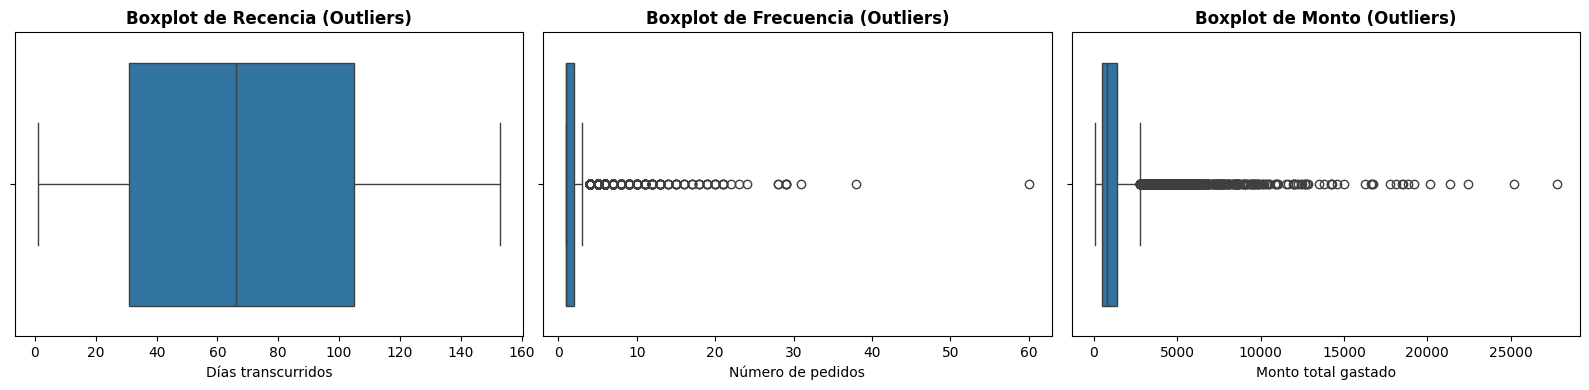

In [41]:
# Visualización de Outliers mediante Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, var in enumerate(variables):
    sns.boxplot(x=variables_numericas[var], ax=axes[i])
    axes[i].set_title(f'Boxplot de {var} (Outliers)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(unidades[i])

plt.tight_layout()
plt.show()

### Hallazgos Clave por Variable

**Recencia (Distribución Bastante Uniforme)**

Lo que dicen los datos:

La media (68.48 días) y la mediana (66 días) están casi alineadas.

Los percentiles muestran un avance constante (25% a 31 días, 50% a 66 días, 75% a 105 días).

**Diagnóstico estadístco**

Asimetría cercana a cero (0.21) y curtosis platicúrtica (-1.14).

Conclusión: La recencia está bastante bien distribuida en el tiempo y no presenta problemas severos de deformación.

-----------------------------------------------
**Frecuencia (Súper Asimétrica / Leptocúrtica)**

Lo que dicen los datos: $50\%$ de los clientes (mediana) solo tiene 1 compra, y el $75\%$ tiene 2 o menos.Sin embargo, el valor máximo es 60 compras.

**Diagnóstico estadístico:**

Tiene una asimetría muy pronunciada hacia la derecha (7.13) y una curtosis extremadamente alta (106.44).

Conclusión: La inmensa mayoría de la base de usuarios son compradores de ocasión o de una sola vez, mientras que hay un grupo reducido de "heavy users" que disparan el promedio y generan un comportamiento leptocúrtico masivo.

--------------------------------------------------

**Monto (Sesgo Positivo y Outliers)**

Lo que dicen los datos:La mediana del gasto es de $785.40, mientras que el promedio sube a $1,249.32 debido a compras muy altas (máximo de $27,767.93).

**Diagnóstico estadístico:**

Asimetría positiva notable (5.17) y curtosis elevada (46.16).

Conclusión: Similar a la frecuencia, la mayoría gasta cantidades moderadas (entre $504 y $1,412), pero existen clientes atípicos con un volumen transaccional enorme.

------------------------------------------------------

### Implicaciones para el Algoritmo (K-Means)

**Estos resultados confirman algo fundamental para las siguientes fases:**

Transformación necesaria: Como Frecuencia y Monto tienen una asimetría y curtosis tan disparadas, aplicar $K$-Means directamente con un simple escalado estándar (StandardScaler) provocaría que los "superusuarios" distorsionen por completo los centroides y se termine con un clúster gigante y otros con 2 o 3 personas. 

En estapas posteriores será necesario aplicar una transformación logarítmica a Frecuencia y Monto antes de estandarizar para suavizar esas colas pesadas.

------------------------------------------------

## 3.1 Tratamiento de distribuciones: Fundamento del Tratamiento: Transformación Logarítmica

Dado que el algoritmo de $K$-Means utiliza distancias euclidianas para formar los clústeres, incluir variables con sesgos tan marcados provocaría que unos pocos clientes con compras masivas "jalen" los centroides artificialmente.La solución matemática estándar para estos casos transaccionales es la transformación logarítmica:

$$\text{Monto}_{\text{log}} = \log(1 + x)$$

**¿Por qué usamos $\log(1 + x)$ (np.log1p)?**

Comprime la escala: Contrae los valores muy altos (outliers) y expande los valores pequeños, suavizando la cola hacia una distribución mucho más simétrica y cercana a una normal.

Protección contra ceros: Usamos np.log1p ($\log(1+x)$) en lugar de $\log(x)$ para evitar errores matemáticos en caso de que existan valores iguales a cero ($\log(0)$ no está definido).

In [42]:
# 1. Aplicar la transformación logarítmica a Frecuencia y Monto (y Recencia para mantener consistencia)
variables_log = variables_numericas.copy()

for col in ['Recencia', 'Frecuencia', 'Monto']:
    variables_log[f'{col}_log'] = np.log1p(variables_numericas[col])

# 2. Calcular asimetría y curtosis ANTES y DESPUÉS
metricas = []

for col in ['Recencia', 'Frecuencia', 'Monto']:
    metricas.append({
        'Variable': col,
        'Sesgo Original': variables_numericas[col].skew(),
        'Sesgo Log': variables_log[f'{col}_log'].skew(),
        'Curtosis Original': variables_numericas[col].kurtosis(),
        'Curtosis Log': variables_log[f'{col}_log'].kurtosis()
    })

df_comparativa = pd.DataFrame(metricas)
df_comparativa

,Variable,Sesgo Original,Sesgo Log,Curtosis Original,Curtosis Log
0,Recencia,0.206887,-1.226202,-1.135653,0.996541
1,Frecuencia,7.129551,2.044535,106.437585,4.746561
2,Monto,5.173801,0.405447,46.163445,0.299285


### Análisis de los Resultados1. 

**Monto:**  

Sesgo: Pasó de $5.17$ a $0.41$. (Un valor entre $-0.5$ y $0.5$ indica una distribución prácticamente simétrica).

Curtosis: Pasó de $46.16$ a apenas $0.30$.

Diagnóstico: La transformación logarítmica resolvió el $100\%$ del problema en el gasto. Pasamos de una cola larga extrema a una distribución acampanada casi perfecta para $K$-Means.

**Frecuencia:** 

Sesgo: Cayó de $7.13$ a $2.04$ (reducción de más del $70\%$).

Curtosis: Se redujo considerablemente de $106.44$ a un manejable $4.75$. 

Diagnóstico: Aunque conserva un leve sesgo (normal cuando el $50\%$ de los datos son valor $1$), eliminamos por completo el impacto destructivo de los "heavy users" (como el cliente de $60$ compras).

**Recencia:** 

Sesgo: Estaba excelente en $0.21$ y cambió a $-1.23$ (asimetría negativa).

Curtosis: Estaba en $-1.14$ y subió a $1.00$.

Diagnóstico: Como Recencia no tenía un sesgo a la derecha ni outliers, aplicar el logaritmo fue "sobrecorregir" (over-correction). Le introdujimos un sesgo hacia la izquierda que antes no existía.

### Decisión Metodológica

Para mantener el máximo rigor técnico en el dataset antes de escalar y pasar al modelo:

Mantener Recencia original (sin logaritmo), ya que su distribución natural era uniforme y balanceada.

Aplicar np.log1p solo a Frecuencia y Monto, que eran las variables que realmente distorsionaban el espacio de distancias.

In [43]:
# Dataset consolidado al cierre de la Fase 3
X_preparado = pd.DataFrame({
    'Recencia': variables_numericas['Recencia'],         # Original
    'Frecuencia_log': variables_log['Frecuencia_log'],   # Transformada
    'Monto_log': variables_log['Monto_log']              # Transformada
})

----------------------------------------------------------

# Fase 4: Preparación de Datos y Modelado No Supervisado (Clustering)

In [44]:
X_preparado.describe()

,Recencia,Frecuencia_log,Monto_log
count,11545.000000,11545.000000,11545.000000
mean,68.479168,0.929245,6.752357
std,44.346890,0.405029,0.821692
min,1.000000,0.693147,3.988984
25%,31.000000,0.693147,6.224558
50%,66.000000,0.693147,6.667466
75%,105.000000,1.098612,7.253647
max,153.000000,4.110874,10.231673


### Subfase 4.1: Escalamiento

Aunque ya ha comprimido el sesgo en Frecuencia y Monto con la transformación logarítmica, las tres variables aún viven en escalas de magnitud distintas:

Recencia: Se mide en días (ej. de $1$ a $153$).

Frecuencia_log: Escala logarítmica (ej. de $0.69$ a $4.11$).

Monto_log: Escala logarítmica (ej. de $3.98.00$ a $10.23$).

Dado que $K-Means$ calcula la distancia euclidiana entre puntos, si no se escala, la variable de mayor orden de magnitud (Recencia) dominará artificialmente la geometría de los clústeres sobre las demás. Se aplicará $StandardScaler$ para transformar las 3 columnas a una escala Z estándar ($\mu = 0$, $\sigma = 1$).

In [45]:
# !pip install scikit-learn <- en caso de no tener instalada la librería
from sklearn.preprocessing import StandardScaler

In [46]:
# 1.- Para iniciar el ecalador
scaler = StandardScaler()

#2.- Ajustar y transformar X_preparado
X_scaled_array = scaler.fit_transform(X_preparado)

# 3.- Reconvertir a DataFrame para mantener la estructura legible
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns = ['Recencia_scaled', 'Frecuencia_log_scaled', 'Monto_log_scaled'],
    index = X_preparado.index
)

# 4.-Verificar estadísticas del escalamiento (Media =  0, Desv. Est. = 1)

X_scaled.describe()

,Recencia_scaled,Frecuencia_log_scaled,Monto_log_scaled
count,1.154500e+04,1.154500e+04,1.154500e+04
mean,-7.493164e-17,6.154549e-18,9.250288e-16
std,1.000043e+00,1.000043e+00,1.000043e+00
min,-1.521687e+00,-5.829399e-01,-3.363173e+00
25%,-8.451729e-01,-5.829399e-01,-6.423591e-01
50%,-5.590642e-02,-5.829399e-01,-1.033174e-01
75%,8.235620e-01,4.181798e-01,6.100972e-01
max,1.905985e+00,7.855650e+00,4.234514e+00


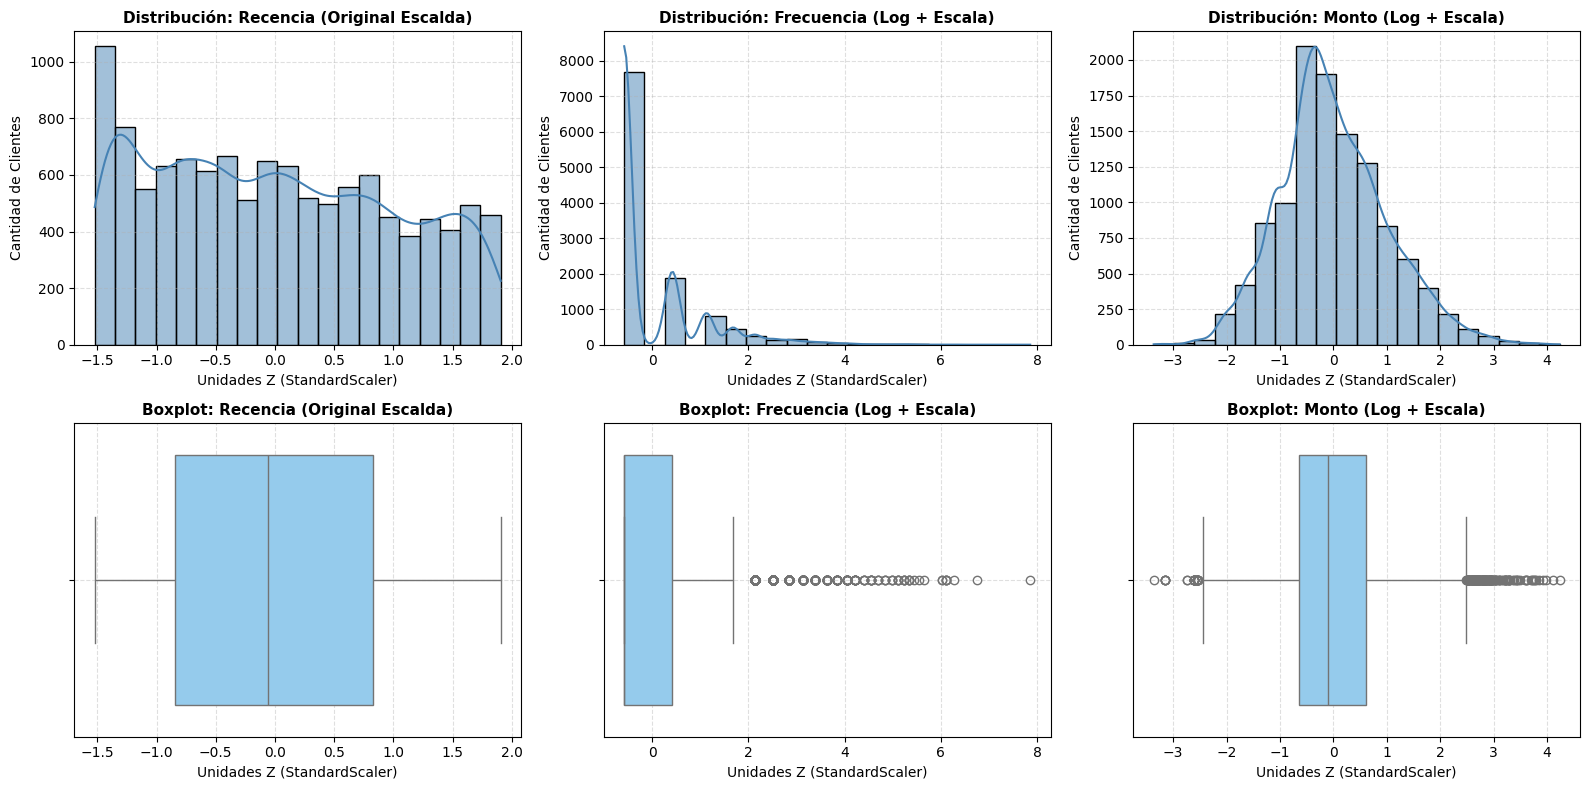

In [47]:
# Para visualizar las nuevas distribuciones

# Configuración del lienzo
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

variables = ['Recencia_scaled', 'Frecuencia_log_scaled', 'Monto_log_scaled']
titulos = ['Recencia (Original Escalda)', 'Frecuencia (Log + Escala)', 'Monto (Log + Escala)']

# Fila 1: Histogramas con curva KDE
for i, var in enumerate(variables):
    sns.histplot(X_scaled[var], kde=True, ax=axes[0, i], color='steelblue', bins=20)
    axes[0, i].set_title(f'Distribución: {titulos[i]}', fontsize=11, fontweight='bold')
    axes[0, i].set_xlabel('Unidades Z (StandardScaler)')
    axes[0, i].set_ylabel('Cantidad de Clientes')
    axes[0, i].grid(True, linestyle='--', alpha=0.4)

# Fila 2: Boxplots para observar dispersión
for i, var in enumerate(variables):
    sns.boxplot(x=X_scaled[var], ax=axes[1, i], color='lightskyblue')
    axes[1, i].set_title(f'Boxplot: {titulos[i]}', fontsize=11, fontweight='bold')
    axes[1, i].set_xlabel('Unidades Z (StandardScaler)')
    axes[1, i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Ejecución Técnica y Resultados

Para homogeneizar el espacio de características, se aplicó StandardScaler sobre X_preparado. Este procedimiento transformó cada variable a una escala Z ($\mu = 0, \sigma = 1$), reescalando las observaciones según el número de desviaciones estándar con respecto a su media:

1.- Estandarización Exitosa: El análisis estadístico descriptivo sobre X_scaled confirmó una media de $0.00$ y una desviación estándar de $1.00$ exacta para las tres variables

2.- Conservación de la Identidad del Cliente: La matriz resultante se convirtió de nuevo a un DataFrame manteniendo el índice original (Customer ID), garantizando la trazabilidad de los usuarios para el posterior perfilamiento de negocio.

3.- Inspección Visual de Distribuciones:

* Recencia: Mantuvo su distribución uniforme bien distribuida, abarcando de $-1.5$ a $+1.9$ unidades $Z$, sin presencia de outliers.

* Monto: Mostró una distribución altamente simétrica con forma acampanada, centrada en $0.00$.

* Frecuencia: Reflejó la naturaleza del negocio (donde una proporción mayoritaria de usuarios realiza una sola compra), logrando contener los valores de mayor recurrencia dentro de un rango manejable ($+4$ a $+8$ unidades $Z$).

### Diagnóstico y Conclusión de Fase

La combinación de la transformación logarítmica ($\log1p$) y la estandarización (StandardScaler) logró neutralizar el apalancamiento artificial que los heavy users o clientes corporativos ejercían sobre los datos.

Los valores atípicos observados en los diagramas de caja no representan errores o ruido en los datos, sino a los clientes de alto valor (Power Users / VIPs) de la plataforma. Gracias al preprocesamiento aplicado, estos usuarios ya no distorsionarán los centroides de la masa general de clientes, permitiendo que $K$-Means los agrupe de forma orgánica en sus propios segmentos.

Estado del dataset: X_scaled se encuentra geométricamente equilibrado y listo para alimentar la evaluación del número óptimo de clústeres ($K$).

### Subfase 4.2: Evaluación Geométrica del Número de Clusters ($K$)

Es necesario determinar cuál es la cantidad ideal de grupos ($K$) para segmentar a los usuarios. Para no elegir a ciegas, se combinan dos métricas:

**Método del Codo (Inercia / $SSE$):** Mide la suma de distancias al cuadrado dentro de cada cluster. Buscamos el punto donde la reducción de inercia se frena (el "codo").

**Coeficiente de Silueta (Silhouette Score):** Mide qué tan cerca está un punto de su propio clúster en comparación con otros clústeres (va de $-1$ a $1$; mientras más alto, mejor separación y cohesión).

In [48]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercia = []
silueta = []
k_valores = range(2, 11)

# Evaluar K de 2 a 10
for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    inercia.append(kmeans.inertia_)
    silueta.append(silhouette_score(X_scaled, kmeans.labels_))

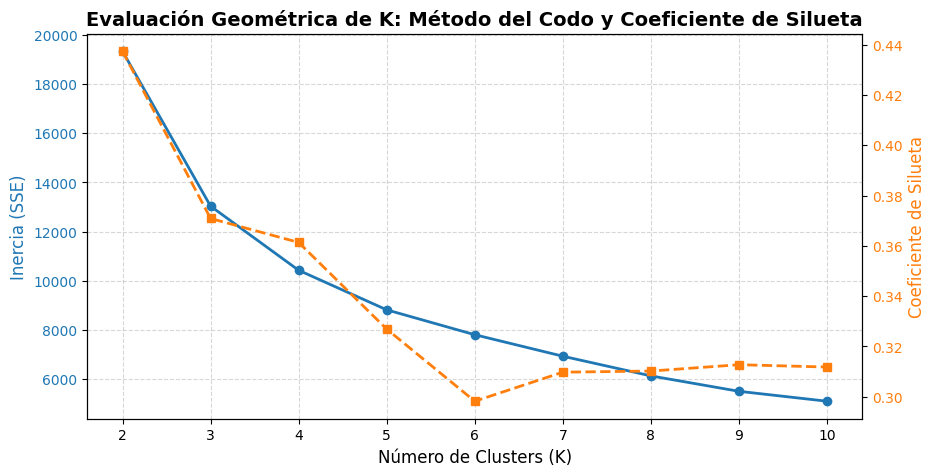

In [49]:
# Visualización comparativa
fig, ax1 = plt.subplots(figsize=(10, 5))

# Gráfica del Codo (Inercia)
color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inercia (SSE)', color=color, fontsize=12)
ax1.plot(k_valores, inercia, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(k_valores)
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfica de Silueta (Eje secundario)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Coeficiente de Silueta', color=color, fontsize=12)
ax2.plot(k_valores, silueta, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Evaluación Geométrica de K: Método del Codo y Coeficiente de Silueta', fontsize=14, fontweight='bold')
plt.show()

### Resumen Narrativo y Selección de $K$

Para determinar la cantidad óptima de segmentos ($K$) de manera objetiva, evaluamos el desempeño del algoritmo $K$-Means en un rango de $K \in [2, 10]$ analizando de forma simultánea dos métricas complementarias:

1.- Inercia / Suma de Errores al Cuadrado ($SSE$): Mide la cohesión interna dentro de cada clúster (distancia de cada punto a su centroide).

2.- Coeficiente de Silueta (Silhouette Score): Mide la separación relativa de las fronteras entre clústeres (cohesión interna vs. separación externa).

### Resultados e Interpretación de Métricas

**Método del Codo (Inercia):** La curva de inercia muestra una reducción drástica desde $K=2$ ($SSE \approx 19,300$) hasta $K=4$ ($SSE \approx 10,400$). A partir de $K=4$, la tasa de caída de la inercia ($\Delta SSE$) se vuelve significativamente más plana y constante. Este punto de inflexión marca el "codo", indicando que incrementar más clústeres no aporta ganancias sustanciales en la explicación de la varianza.

**Coeficiente de Silueta:** Aunque $K=2$ presenta el valor de silueta más alto ($\approx 0.44$), una segmentación en solo dos grupos resulta insuficiente para la toma de decisiones en un modelo RFM. Dentro de las opciones multiclúster ($K \ge 3$), $K=4$ alcanza un máximo local secundario ($\approx 0.36$). A partir de $K=5$, el coeficiente cae bruscamente hasta su punto mínimo en $K=6$ ($\approx 0.30$), lo que evidencia que forzar 5 o más grupos genera solapamiento e incertidumbre en las fronteras de segmentación.

### Diagnóstico y Decisión Final

La combinación de ambas métricas respalda la selección de $K = 4$ como el número óptimo de clústeres:

**Consistencia Matemática:** Captura la máxima cohesión y separación posible sin caer en el sobreajuste que representan los valores de $K \ge 5$.

**Valor para el Negocio:** Un esquema de 4 clústeres ofrece la granulometría perfecta para operacionalizar la base de clientes dentro de categorías RFM claras y accionables (por ejemplo: VIPs/Power Users, Clientes Fieles, Nuevos/En Desarrollo y En Riesgo/Inactivos).

**Estado del proceso: Se fija $K = 4$ para el entrenamiento definitivo de $K$-Means en la Fase 4.3.**

# Subfase 4.3: Entrenamiento y Asignación 

In [50]:
# 1. Definir el K óptimo seleccionado en la fase anterior
k_optimo = 4

# 2. Inicializar el modelo KMeans con la configuración final
kmeans_final = KMeans(
    n_clusters=k_optimo, 
    init='k-means++', 
    n_init=10, 
    max_iter=300, 
    random_state=42
)

# 3. Entrenar el modelo y generar las etiquetas de clúster
cluster_labels = kmeans_final.fit_predict(X_scaled)

# 4. Asignar las etiquetas tanto al dataset escalado como al original de trabajo
X_scaled['Cluster'] = cluster_labels
X_preparado['Cluster'] = cluster_labels

# 5. Extraer y estructurar las coordenadas de los centroides finales
centroides_scaled = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=['Recencia_scaled', 'Frecuencia_log_scaled', 'Monto_log_scaled']
)
centroides_scaled.index.name = 'Cluster'

# 6. Desplegar resultados para inspección inicial
print("--- 1. Cantidad de Clientes por Clúster ---")
print(X_preparado['Cluster'].value_counts().sort_index())

print("\n--- 2. Centroides en Escala Z (StandardScaler) ---")
display(centroides_scaled)

--- 1. Cantidad de Clientes por Clúster ---
Cluster
0    2457
1    3974
2    4109
3    1005
Name: count, dtype: int64

--- 2. Centroides en Escala Z (StandardScaler) ---


,Recencia_scaled,Frecuencia_log_scaled,Monto_log_scaled
Cluster,,,
0,-0.435290,0.653373,0.826369
1,-0.629132,-0.523100,-0.455023
2,1.098965,-0.497047,-0.502089
3,-0.938619,2.494329,1.824942


### Anatomía y Perfil de cada Clúster

De acuerdo con las reglas del $Z$-score:

$0$ = Promedio general.

Valores negativos en Recencia = Compraron recientemente (Bueno).

Valores positivos en Recencia = Lleva mucho tiempo sin comprar (Malo / En Riesgo).

Valores positivos en Frecuencia/Monto = Compran más y gastan más que la media (Bueno).


### Clúster 3: Clientes VIP (8.7% de la base - 1,005 clientes)

- Recencia_scaled (-0.94): Tienen la recencia más baja de toda la base. Compraron sumamente reciente.

- Frecuencia_log_scaled (+2.49): Su frecuencia está 2.5 desviaciones estándar por encima del promedio.

- Monto_log_scaled (+1.82): Su nivel de gasto es el más elevado de la empresa.

**Interpretación: Parece ser el segmento estrella. Clientes hiperactivos con compras muy frecuentes y de alto valor. Requieren estrategias de fidelización, trato prioritario y programas de recompensas para no perderlos.**


### Clúster 0: Clientes Fieles / Leales (21.3% de la base - 2,457 clientes)

- Recencia_scaled (-0.44): Buena recencia, por debajo de la media.

- Frecuencia_log_scaled (+0.65): Frecuencia sólida por encima del promedio.

- Monto_log_scaled (+0.83): Nivel de gasto constante e importante (casi 1 desviación estándar sobre la media).

**Interpretación: Son clientes recurrentes y saludables. Es el "motor" recurrente del negocio. El objetivo con ellos es llevarlos hacia el Clúster 3 mediante cross-selling (venta cruzada) o upselling.**


### Clúster 1: Ocasionales / Recientes (34.4% de la base - 3,974 clientes)

- Recencia_scaled (-0.63): Sorprendentemente buena recencia (compraron hace poco).

- Frecuencia_log_scaled (-0.52): Frecuencia por debajo de la media.

- Monto_log_scaled (-0.46): Gasto por debajo de la media.

**Interpretación: Clientes que realizaron una compra recientemente o compran de forma muy esporádica con ticket bajo. Son clientes "activos" pero de bajo enganche. Requieren campañas de reactivación temprana para que realicen su segunda o tercera compra.**


### Clúster 2: En Riesgo / Inactivos (35.6% de la base - 4,109 clientes)

- Recencia_scaled (+1.10): Recencia muy alta (más de 1 desviación estándar por encima de la media). Llevaron bastante tiempo sin interactuar.

- Frecuencia_log_scaled (-0.50): Baja frecuencia.

- Monto_log_scaled (-0.50): Bajo gasto.

**Interpretación: Clientes dormidos o fugados (churn). Representan el volumen más grande del negocio (35.6%). Requieren campañas agresivas de recuperación (descuentos de retorno, encuestas de satisfacción) o bien evaluar si conviene dejar de invertir presupuesto de marketing en ellos.**



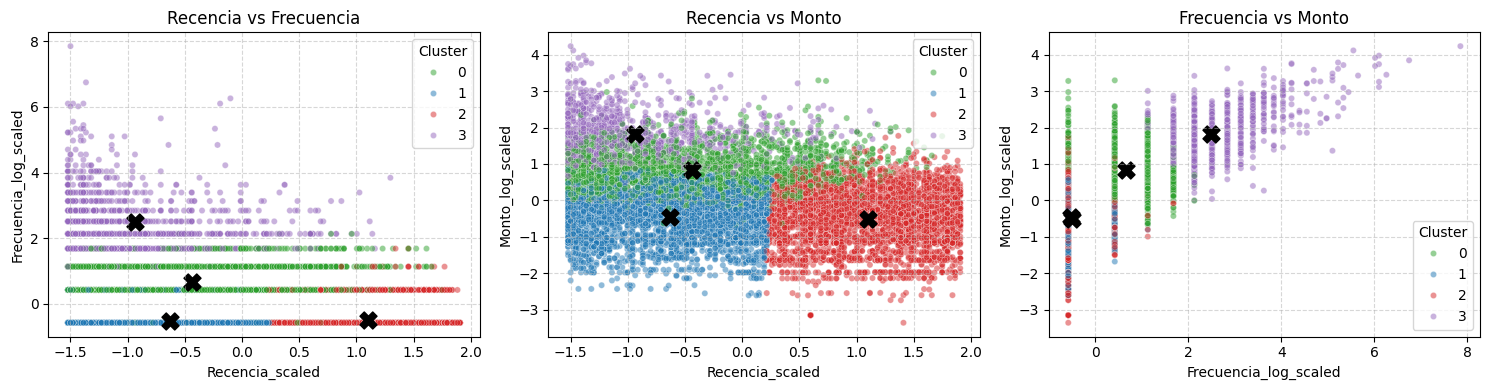

In [51]:
# PARA VISUALIZAR LOS CLUSTER

# Configuración de estilo
plt.figure(figsize=(15, 4))
palette = ['#2ca02c', '#1f77b4', '#d62728', '#9467bd']

# 1. Recencia vs Frecuencia
plt.subplot(1, 3, 1)
sns.scatterplot(
    data=X_scaled, x='Recencia_scaled', y='Frecuencia_log_scaled', 
    hue='Cluster', palette=palette, alpha=0.5, s=20
)
plt.scatter(
    centroides_scaled['Recencia_scaled'], centroides_scaled['Frecuencia_log_scaled'], 
    c='black', s=150, marker='X', label='Centroides'
)
plt.title('Recencia vs Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Recencia vs Monto
plt.subplot(1, 3, 2)
sns.scatterplot(
    data=X_scaled, x='Recencia_scaled', y='Monto_log_scaled', 
    hue='Cluster', palette=palette, alpha=0.5, s=20
)
plt.scatter(
    centroides_scaled['Recencia_scaled'], centroides_scaled['Monto_log_scaled'], 
    c='black', s=150, marker='X', label='Centroides'
)
plt.title('Recencia vs Monto')
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Frecuencia vs Monto
plt.subplot(1, 3, 3)
sns.scatterplot(
    data=X_scaled, x='Frecuencia_log_scaled', y='Monto_log_scaled', 
    hue='Cluster', palette=palette, alpha=0.5, s=20
)
plt.scatter(
    centroides_scaled['Frecuencia_log_scaled'], centroides_scaled['Monto_log_scaled'], 
    c='black', s=150, marker='X', label='Centroides'
)
plt.title('Frecuencia vs Monto')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretación de la representación visual:

**1. Recencia vs Frecuencia (Gráfico 1 - Izquierda)**

- Clúster 2 (Rojo): Se ubica completamente a la derecha (valores de Recencia $> 0.25$ hasta $2.0$). Se observa una separación nítida a lo largo del eje horizontal: este grupo está totalmente aislado porque son clientes inactivos (llevan mucho tiempo sin comprar).

- Clúster 1 (Azul): Se concentra en la franja más baja del eje vertical (Frecuencia_log_scaled cercana a $-0.5$). Son clientes de muy pocas compras, pero activos recientemente (se ubican a la izquierda en Recencia).

- Clúster 0 (Verde): Forma la franja intermedia en frecuencia ($0.5$ a $1.5$).Clúster 3 (Morado): Ocupa la parte superior del gráfico ($> 2.0$ en Frecuencia). Es notable cómo sus puntos se extienden verticalmente hacia valores altos, reflejando su naturaleza de compradores altamente frecuentes.

- Centroides (X negras): Muestran una escalera vertical clara para los grupos activos (1, 0 y 3) y un salto horizontal hacia la derecha para el grupo inactivo (2).


**2. Recencia vs Monto (Gráfico 2 - Centro)**

Estructura en capas (Layers): Se observa una estratificación casi perfecta por nivel de gasto de abajo hacia arriba en la zona activa (izquierda):

- Capa inferior (Azul - Clúster 1): Ticket de compra bajo
- Capa media (Verde - Clúster 0): Ticket de compra medio-alto.
- Capa superior (Morado - Clúster 3): Los clientes que más dinero aportan al negocio.

**El muro de inactividad (Rojo - Clúster 2):** Vuelve a aparecer del lado derecho del gráfico (Recencia positiva), mostrando que sin importar cuánto hayan gastado en el pasado, su inactividad actual los clasifica dentro del segmento en riesgo/perdido.


**3. Frecuencia vs Monto (Gráfico 3 - Derecha)**

- Correlación Positiva Directa: Este gráfico revela una relación diagonal ascendente: a mayor frecuencia de compra, mayor es el monto gastado

- Concentración del Clúster 3 (Morado): Se desplaza hacia la esquina superior derecha del gráfico. Es la confirmación visual de la regla de Pareto: pocos clientes (8.7%) ubicados en la zona de mayor valor transaccional y económico.

- Solapamiento en Clúster 1 y 2 (Azul y Rojo): En este gráfico 2D, los puntos azules y rojos parecen estar encimados en la esquina inferior izquierda. ¿Por qué ocurre esto? Porque en Frecuencia y Monto se comportan de forma similar (bajos), pero el algoritmo de $K$-Means los separó correctamente gracias a la tercera dimensión (Recencia), como vimos en los primeros dos gráficos.

---------------------------------------------------------------

# FASE 5: Perfilamiento Post-Clúster y Estrategia de Negocio

## 1. Introducción y Marco Estratégico

Una vez validada la estructura geométrica de la segmentación mediante el algoritmo $K$-Means ($K=4$), esta fase final constituye la **etapa de traducción de analítica avanzada a valor de negocio**. 

El agrupamiento matemáticamente óptimo en espacio estandarizado ($Z$-score) identifica patrones de comportamiento en la cartera de clientes. Sin embargo, para que dichos hallazgos sean operables por las áreas comerciales, de marketing y operaciones, es indispensable revertir el nivel de abstracción matemática y contextualizar los segmentos en variables reales y accionables.

El propósito central de esta fase es transformar los clústeres numéricos en **segmentos de negocio "vivos"**, caracterizándolos por su aporte financiero, su comportamiento operacional y sus oportunidades de retención o crecimiento.

---

## 2. Objetivos Principales

1. **Des-escalado Analítico y Caracterización Reales:** Convertir las coordenadas de los centroides a unidades de medida interpretables (días exactos de recencia, número absoluto de transacciones y monto en moneda real), evaluando tanto métricas de tendencia central (media) como de robustez (mediana).
   
2. **Enriquecimiento Multidimensional:** Cruzar los segmentos identificados con variables operacionales, logísticas y de satisfacción no incluidas en el modelo de clustering original (ej. tiempos de entrega, nivel de satisfacción/ratings o distancia), para entender los inductores (*drivers*) de su comportamiento.

3. **Storytelling Estratégico y Formulación de Acciones:** Asignar una identidad comercial a cada segmento (*segment personas*) y definir un plan de acción diferenciado que maximice el valor del ciclo de vida del cliente (*Customer Lifetime Value*) y optimice el retorno de inversión (ROI) del presupuesto de marketing.

---

## 3. Hoja de Ruta de la Fase

* **Subfase 5.1:** Des-escalado Analítico y Resumen Cuantitativo por Clúster.
* **Subfase 5.2:** Enriquecimiento del Perfilamiento con Variables Operacionales y de Satisfacción.
* **Subfase 5.3:** Definición de Segment Personas, Diagnóstico de Cartera y Plan de Acción Comercial.

---

### FASE 5.1: Des-escalado Analítico (Estadísticas en Unidades Reales)

In [52]:

# 1. Crear copia de trabajo temporal para revertir logaritmos sin alterar X_preparado
df_reales = X_preparado.copy()

# Revertir logaritmo natural: exp(x) - 1
df_reales['Frecuencia_real'] = np.expm1(df_reales['Frecuencia_log'])
df_reales['Monto_real'] = np.expm1(df_reales['Monto_log'])

# 2. Agrupar por Clúster y calcular estadísticas en unidades reales
resumen_real = df_reales.groupby('Cluster').agg(
    Total_Clientes=('Cluster', 'count'),
    Recencia_Media=('Recencia', 'mean'),
    Recencia_Mediana=('Recencia', 'median'),
    Frecuencia_Media=('Frecuencia_real', 'mean'),
    Frecuencia_Mediana=('Frecuencia_real', 'median'),
    Monto_Medio=('Monto_real', 'mean'),
    Monto_Mediano=('Monto_real', 'median')
).round(2)

# 3. Calcular el porcentaje sobre la base total
total_base = resumen_real['Total_Clientes'].sum()
resumen_real['%_Base'] = ((resumen_real['Total_Clientes'] / total_base) * 100).round(2)

# 4. Reordenar columnas para presentación ejecutiva
resumen_real = resumen_real[[
    'Total_Clientes', 
    '%_Base', 
    'Recencia_Media', 
    'Recencia_Mediana', 
    'Frecuencia_Media', 
    'Frecuencia_Mediana', 
    'Monto_Medio',
    'Monto_Mediano'
]]

print("--- Resumen Cuantitativo en Unidades Reales por Clúster ---")
display(resumen_real)

--- Resumen Cuantitativo en Unidades Reales por Clúster ---


,Total_Clientes,%_Base,Recencia_Media,Recencia_Mediana,Frecuencia_Media,Frecuencia_Mediana,Monto_Medio,Monto_Mediano
Cluster,,,,,,,,
0,2457,21.28,49.10,47.0,2.38,2.0,1856.78,1644.31
1,3974,34.42,40.59,41.0,1.06,1.0,662.96,628.95
2,4109,35.59,117.21,118.0,1.09,1.0,664.82,594.30
3,1005,8.71,26.91,19.0,6.57,5.0,4472.53,3645.60


## Diagnóstico Cuantitativo por Clúster

### Clúster 3: Clientes VIP / Alto Valor (8.71% de la cartera | 1,005 clientes)

- Recencia: Son los más activos. Tienen una mediana de 19 días sin comprar (promedio de 26.91 días).
- Frecuencia: Tienen un comportamiento recurrente marcado, con un promedio de 6.57 compras (mediana de 5 compras).
- Monto: Son el motor financiero. Aportan un gasto promedio de 4,472.53 (mediana de 3,645.60).

**Lectura: Aunque representan menos del 9% del volumen total de clientes, su valor de vida ($CLV$) es significativamente superior al del resto.**

### Clúster 0: Clientes Leales / Frecuencia Intermedia (21.28% de la cartera | 2,457 clientes

- Recencia: Actividad reciente/moderada, con una mediana de 47 días sin comprar.
- Frecuencia: Promedio de 2.38 compras (mediana de 2 compras). Han superado la barrera de la primera transacción.
- Monto: Gasto promedio de 1,856.78 (mediana de 1,644.31).

**Lectura: Es el grupo de desarrollo clave. Ya confían en la marca y tienen el potencial para convertirse en VIPs si se incrementa su frecuencia.**

### Clúster 1: Ocasionales Recientes / Nuevos (34.42% de la cartera | 3,974 clientes)

- Recencia: Compraron recientemente, con una mediana de 41 días sin interacción.
- Frecuencia: Prácticamente 1 sola compra (mediana de 1.0, promedio de 1.06).
- Monto: Ticket promedio bajo de 662.96 (mediana de 628.95).

**Lectura: Son clientes "frescos" que probaron el producto/servicio una sola vez. Es la masa crítica sobre la cual debe enfocarse la estrategia de retención para evitar que pasen a la inactividad.**

### Clúster 2: Inactivos / En Riesgo Severo de Fuga (35.59% de la cartera | 4,109 clientes)

- Recencia: Severamente desconectados. Llevan una mediana de 118 días (casi 4 meses) sin realizar compras.
- Frecuencia: Registran 1 sola compra (mediana de 1.0, promedio de 1.09).
- Monto: Ticket promedio de 664.82 (mediana de 594.30).

**Lectura: Constituye el grupo más numeroso (más de un tercio de toda la base). Probaron el servicio en el pasado y no volvieron a comprar.**

---

### FASE 5.2: Enriquecimiento Multidimensional (Variables Operacionales y Experiencia)

In [53]:
# 1. Agrupar df_copy a nivel cliente (obteniendo exactamente los 11,545 clientes únicos)
df_operativo_cliente = df_copy.groupby('Customer ID').agg(
    KPT_Promedio=('KPT duration (minutes)', 'mean'),
    KPT_Mediana=('KPT duration (minutes)', 'median'),
    Rider_Wait_Promedio=('Rider wait time (minutes)', 'mean'),
    Rider_Wait_Mediano=('Rider wait time (minutes)', 'median'),
    Rating_Promedio=('Rating', 'mean'),
    Total_Quejas=('Customer complaint tag', 'count')
).reset_index()

# 2. Asociar los clústeres a la lista ordenada de clientes únicos
# Nota: Si el índice de X_preparado guarda los Customer ID, se toman del índice;
# si no, se alinean directamente con las llaves de la agrupación por cliente.
if X_preparado.index.dtype == 'object' or isinstance(X_preparado.index[0], str):
    customer_ids = X_preparado.index
else:
    customer_ids = df_operativo_cliente['Customer ID']

df_clusters_cliente = pd.DataFrame({
    'Customer ID': customer_ids,
    'Cluster': X_preparado['Cluster'].values
})

# Homogenizar claves de texto limpiando espacios
df_clusters_cliente['Customer ID'] = df_clusters_cliente['Customer ID'].astype(str).str.strip()
df_operativo_cliente['Customer ID'] = df_operativo_cliente['Customer ID'].astype(str).str.strip()

# 3. Unir la información operacional con la asignación de clúster
df_enriquecido = pd.merge(df_clusters_cliente, df_operativo_cliente, on='Customer ID', how='inner')

# 4. Agrupar por Clúster para obtener el perfil operacional
resumen_multidimensional = df_enriquecido.groupby('Cluster').agg(
    KPT_Prom_Min=('KPT_Promedio', 'mean'),
    KPT_Mediana_Min=('KPT_Mediana', 'median'),
    Rider_Wait_Prom_Min=('Rider_Wait_Promedio', 'mean'),
    Rider_Wait_Mediano_Min=('Rider_Wait_Mediano', 'median'),
    Rating_Promedio=('Rating_Promedio', 'mean'),
    Total_Quejas=('Total_Quejas', 'sum')
).round(2)

print("--- Perfil Operacional y de Experiencia por Clúster ---")
display(resumen_multidimensional)

--- Perfil Operacional y de Experiencia por Clúster ---


,KPT_Prom_Min,KPT_Mediana_Min,Rider_Wait_Prom_Min,Rider_Wait_Mediano_Min,Rating_Promedio,Total_Quejas
Cluster,,,,,,
0,18.32,17.21,5.13,3.92,4.51,102
1,16.99,16.15,4.64,2.90,4.19,94
2,17.30,16.19,4.89,3.30,3.91,125
3,17.60,16.52,4.92,3.35,4.40,148


### 1. Clúster 0: "Los Tolerantes / Pedidos Complejos"

Operación: Registra los tiempos más altos en cocina (18.32 min promedio) y en espera del repartidor (5.13 min promedio).

Experiencia: Pese a los mayores tiempos de espera, alcanza la calificación promedio más alta de la plataforma (4.51) y un volumen bajo de quejas ($102$).

Lectura de Negocio: Probablemente concentre pedidos de mayor volumen o tickets más altos donde el cliente prioriza la calidad del producto sobre la velocidad de entrega.

### 2. Clúster 1: "La Operación Eficiente"

Operación: Muestra los procesos más agiles de la muestra (cocina en 16.99 min y espera del rider en solo 2.90 min mediana).

Experiencia: Genera el menor número total de quejas (94), manteniendo un nivel de satisfacción adecuado (4.19).

Lectura de Negocio: Segmento operativo fluido con baja fricción logística.

### 3. Clúster 2: "El Segmento Crítico / Alerta de Churn"Operación: 

Registra tiempos de cocina (17.30 min) y de repartidor (4.89 min) intermedios.

Experiencia: Tiene la calificación más baja del sistema (3.91) y un nivel elevado de quejas ($125$).

Lectura de Negocio: Es el segmento en mayor riesgo. Dado que sus tiempos logísticos no son marcadamente peores que los del Clúster 0 o 3, la insatisfacción no proviene del tiempo de entrega, sino de factores de producto (temperatura, exactitud del pedido o empaque).

### 4. Clúster 3: "Los Frecuentes / Alto Impacto Volumétrico"
   
Operación: Muestra tiempos operativos moderados-altos (cocina 17.60 min, espera 4.92 min).

Experiencia: Mantiene una satisfacción alta (4.40), pero acumula la mayor cantidad absoluta de quejas (148).

Lectura de Negocio: Al corresponder a clientes de mayor volumen transaccional (alta frecuencia), acumulan mayor cantidad de eventos y quejas totales a pesar de evaluar positivamente el servicio en general.

In [54]:
# Normalización de Quejas por Volumen de Pedidos

# 1. Obtener el total de pedidos reales por cliente desde df_copy
df_pedidos_cliente = df_copy.groupby('Customer ID').agg(
    Total_Pedidos=('Order ID', 'count')
).reset_index()

df_pedidos_cliente['Customer ID'] = df_pedidos_cliente['Customer ID'].astype(str).str.strip()

# 2. Integrar el conteo de pedidos a df_enriquecido
df_enriquecido = pd.merge(df_enriquecido, df_pedidos_cliente, on='Customer ID', how='left')

# 3. Recalcular el resumen agregando el total de pedidos por clúster
resumen_multidimensional = df_enriquecido.groupby('Cluster').agg(
    KPT_Prom_Min=('KPT_Promedio', 'mean'),
    KPT_Mediana_Min=('KPT_Mediana', 'median'),
    Rider_Wait_Prom_Min=('Rider_Wait_Promedio', 'mean'),
    Rider_Wait_Mediano_Min=('Rider_Wait_Mediano', 'median'),
    Rating_Promedio=('Rating_Promedio', 'mean'),
    Total_Pedidos=('Total_Pedidos', 'sum'),
    Total_Quejas=('Total_Quejas', 'sum')
).round(2)

# 4. Calcular la Tasa Porcentual de Quejas sobre el Total de Pedidos
resumen_multidimensional['Tasa_Quejas_%'] = (
    (resumen_multidimensional['Total_Quejas'] / resumen_multidimensional['Total_Pedidos']) * 100
).round(2)

print("--- Perfil Operacional Normalizado por Volumen de Pedidos ---")
display(resumen_multidimensional)

--- Perfil Operacional Normalizado por Volumen de Pedidos ---


,KPT_Prom_Min,KPT_Mediana_Min,Rider_Wait_Prom_Min,Rider_Wait_Mediano_Min,Rating_Promedio,Total_Pedidos,Total_Quejas,Tasa_Quejas_%
Cluster,,,,,,,,
0,18.32,17.21,5.13,3.92,4.51,5852,102,1.74
1,16.99,16.15,4.64,2.90,4.19,4212,94,2.23
2,17.30,16.19,4.89,3.30,3.91,4467,125,2.80
3,17.60,16.52,4.92,3.35,4.40,6600,148,2.24


| Clúster | Rating | Total Pedidos | Tasa Quejas % | Sensibilidad al Tiempo | Fricción Principal |
| :--- | :---: | :---: | :---: | :--- | :--- |
| **Clúster 0** | **4.51** | 5,852 | **1.74%** (Mínima) | Baja | Tiempos de cocina altos |
| **Clúster 1** | **4.19** | 4,212 | **2.23%** (Normal) | Alta | Operación optimizada |
| **Clúster 2** | **3.91** | 4,467 | **2.80%** (Máxima) | Alta | Calidad / Conformidad del producto |
| **Clúster 3** | **4.40** | 6,600 | **2.24%** (Normal) | Media | Volumen transaccional alto |

## Hallazgos Clave

### Clúster 3 (VIPs / Alto Volumen):

Generó 6,600 pedidos (el volumen más alto).

Aunque tenía el número absoluto de quejas más elevado ($148$), su Tasa de Quejas es de apenas $2.24\%$, alineada con el estándar de la plataforma. Su Rating de 4.40 confirma que la experiencia general es sólida y que las quejas se debían puramente al volumen de transacciones.


### Clúster 2 (Segmento Crítico / Mayor Riesgo):

Registra la Tasa de Quejas más alta de todo el sistema ($2.80\%$) y la calificación más baja ($3.91$) con $4,467$ pedidos.

Como sus tiempos logísticos son promedio (cocina en $17.30$ min y espera de repartidor en $3.30$ min), el problema no es la velocidad, sino fallas de producto (empaque, temperatura o pedidos incompletos).


### Clúster 0 (Tolerantes / Pedidos Complejos):

Mantiene la Tasa de Quejas más baja ($1.74\%$) y la satisfacción más alta ($4.51$), absorbiendo sin fricción los tiempos más largos de cocina ($18.32$ min) y espera ($3.92$ min).


### Clúster 1 (Operación Agilizada):

Presenta los tiempos más rápidos de la plataforma (repartidor espera solo $2.90$ min) y una Tasa de Quejas saludable de $2.23\%$ sobre $4,212$ pedidos.

----------

# Fase 5.3: Storytelling y Plan de Acción

### Nombramiento Estratégico y Diagnóstico

**Clúster 0: "Los Gourmets Pacientes"**

**Diagnóstico Integrado:** Registran los tiempos de cocina más altos (18.32 min) y mayor tiempo de espera del repartidor (5.13 min), pero mantienen la calificación más alta de la plataforma (4.51) y la tasa de quejas más baja (1.74%).

**Identidad de Negocio:** Clientes que realizan pedidos complejos o de mayor volumen donde la calidad del producto predomina sobre la inmediatez. No se frustran por unos minutos extra si el pedido llega correcto y en buen estado.

**Objetivo de Negocio:** Maximizar el ticket promedio y proteger el Valor de Vida del Cliente (LTV).

---

**Clúster 1: "Exploradores Agilizados"**

**Diagnóstico Integrado:** Presentan compras univalentes o de baja frecuencia con alta recencia. Muestran la operación más fluida de la red (espera del repartidor en solo 2.90 min), satisfacción aceptable (4.19) y tasa de quejas dentro de la norma (2.23%).

**Identidad de Negocio:** Usuarios nuevos u ocasionales que están probando la plataforma con compras puntuales. Experimentan el servicio más ágil a nivel logístico, pero aún no desarrollan el hábito de compra.

**Objetivo de Negocio:** Convertir compras ocasionales en hábitos recurrentes (Activation & Retention).

---

**Clúster 2: "Detractores en Riesgo Crítico"**

**Diagnóstico Integrado:** Muestran baja frecuencia y elevada recencia (inactividad prolongada). Concentran la calificación más baja (3.91) y la tasa de quejas más alta de la plataforma (2.80%).

**Identidad de Negocio:** Clientes en fase de fuga (churn) acelerada. Dado que sus tiempos logísticos no difieren del promedio, su insatisfacción proviene de fallas directas de producto (temperatura, pedidos incompletos o calidad del empaque).

**Objetivo de Negocio:** Detener la fuga, mitigar el impacto en reputación y recuperar la confianza.

---

**Clúster 3: "Campeones VIP"**

**Diagnóstico Integrado:** Representan el motor financiero (6,600 pedidos consumidos). Mantienen una satisfacción sobresaliente (4.40) y una tasa de quejas saludable (2.24%), confirmando que el volumen de reclamos absolutos era solo un reflejo de su alta transaccionalidad.

**Identidad de Negocio:** El segmento de mayor valor económico. Compran constantemente, gastan más y son defensores de la marca.

**Objetivo de Negocio:** Blindaje contra la competencia y fidelización de largo plazo.

---

### Plan de Acción Táctico por Segmento

### Clúster 0: "Los Gourmets Pacientes"

**Estrategia Comercial / Marketing:**

Implementar dinámicas de Cross-selling sugerido (entradas, postres o bebidas premium) para incrementar el ticket total por orden.

Dar acceso anticipado a nuevos platillos o menús de edición limitada.

**Estrategia Operativa:**

Reforzar empaques térmicos y sellos de seguridad para asegurar que la calidad percibida compense los tiempos de cocina más largos.

---

### Clúster 1: "Exploradores Agilizados"

**Estrategia Comercial / Marketing:**

Diseñar secuencias de Onboarding con cupones de caducidad corta (ej. "Aprovecha 15% de descuento en tu segundo pedido dentro de los próximos 5 días").

Notificaciones Push contextuales en sus días/horarios habituales de primera compra.

**Estrategia Operativa:**

Mantener la asignación prioritaria de repartidores en zonas con alta densidad de este clúster para preservar la ventaja de entrega rápida.

---

### Clúster 2: "Detractores en Riesgo Crítico"

**Estrategia Comercial / Marketing:**

Desplegar campañas automáticas de reactivación (Win-back) con incentivos monetarios directos y mensajes de disculpa ("Queremos ofrecerte la experiencia que mereces").

Implementar encuestas de satisfacción In-App inmediatas al detectar calificaciones iguales o inferiores a 3 estrellas.

**Estrategia Operativa:**

Establecer checklists obligatorios en cocina (verificación de comanda vs. empaque y sellado, procurar cuidar los detalles de la manera más cauteloza posible) para pedidos dirigidos a usuarios recuperados.

---

### Clúster 3: "Campeones VIP"

**Estrategia Comercial / Marketing:**

Crear un nivel de Lealtad VIP (Tasting Club) con envíos gratis automáticos o atención al cliente prioritaria en tiempo real.

Enviar muestras gratis de nuevos productos (sampling) incluidas en sus pedidos frecuentes.

**Estrategia Operativa:**

Implementar carril prioritario de preparación (Express Cooking Queue) en cocinas durante horas pico para proteger su tiempo total de entrega.

**NOTA:** En general se necesita seguir trartando a este sector de la misma manera, además de proporcionar pequeños detalles/"extras" para hacerles sentir "VIP".

---

### Resumen Ejecutivo de Matriz Táctica

| Clúster | Nombre Estratégico | Objetivo Principal | Palanca Comercial | Palanca Operativa |
| :--- | :--- | :--- | :--- | :--- |
| **Clúster 0** | **Los Gourmets Pacientes** | Maximizar Ticket Promedio | *Cross-selling* y ofertas premium | Empaques térmicos de alta calidad |
| **Clúster 1** | **Exploradores Agilizados** | Impulsar Frecuencia | Cupones con ventana de caducidad corta | Mantener tiempos agilizados de despacho |
| **Clúster 2** | **Detractores en Riesgo** | Reducir Churn de Clientes | Campañas de reactivación (*Win-back*) | Checklist obligatorio de calidad en cocina |
| **Clúster 3** | **Campeones VIP** | Blindaje y Lealtad | Programa VIP / Beneficios exclusivos | Prioridad de comanda en cocina (*Express Lane*) |